# Budget Compliance

Check whether models actually keep their reasoning below the token budget requested by
the `budget` prompt suffix (TALE-EP style: *"use less than 8000 tokens to reason"*).

The small per-model summary files only hold mean **total** completion tokens, so this
notebook reads the full per-dataset results files and re-tokenizes the reasoning span
of every sample (everything before `</think>`) with the model's own tokenizer. The
budget runs live in `output/budget/{model_key}/`; the baseline onepass runs (no prompt
suffix) in `output/onepass/{model_key}/`. Token counts are cached to
`output/budget/_token_counts/`, so each model/run pair is only tokenized once — delete
a cache file to force a recompute after re-downloading.

Because all runs are greedy (one sample per task), the baseline and budget runs pair
1:1 by task, which lets us measure exactly which over-budget baseline tasks the budget
instruction *rescued* (brought under 8k) and which compliant tasks it pushed over.

Three figures are produced:
- `figures/07_budget_compliance.png` — % of samples with reasoning under 8k tokens,
  per model and benchmark, plus the macro-average over benchmarks
- `figures/07_budget_ecdf.png` — cumulative distribution of reasoning length per model
  (pooled over benchmarks); each curve's height at the 8k line *is* that model's
  compliance rate
- `figures/07_budget_rescue.png` — over-8k rate with and without the budget prompt,
  and the fate of tasks that were over 8k at baseline (rescued vs. still over)

Notes:
- samples that never close their `<think>` block spent the entire 32k generation budget
  reasoning, so they are never compliant
- re-tokenizing decoded text can drift a token or two from the original generation
  counts, which is irrelevant against an 8k threshold
- models whose results are not downloaded yet are skipped with a message, so the
  notebook can be re-run as more results arrive

In [1]:
"""Budget prompt compliance: does reasoning actually stay below the requested 8k tokens?"""

import json
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import yaml
from transformers import AutoTokenizer

None of PyTorch, TensorFlow >= 2.0, or Flax have been found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# --- configuration ---

FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# full per-dataset results files: budget prompt runs and baseline onepass runs
BUDGET_DIR = Path("../output/budget")
BASELINE_DIR = Path("../output/onepass")

# per-model reasoning token counts cached here after the first tokenizer pass
CACHE_DIR = BUDGET_DIR / "_token_counts"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# model registry: maps model keys to huggingface paths (for the tokenizers)
MODELS_YAML = Path("../config/models.yaml")

# max token budget used in all greedy runs
MAX_TOKENS = 32768

# the budget prompt asks for "less than 8000 tokens" of reasoning
REQUESTED_BUDGET = 8000

# reasoning ends at this tag; text without it never left the reasoning phase
CLOSE_TAG = "</think>"

# colours match the SERIES dict in notebooks 02-06. the three qwen models share a
# blue family, so they also get distinct linestyles as a secondary encoding for the
# ecdf figure (colour alone is not enough to separate 8b from 14b)
SERIES: dict[str, dict] = {
    "qwen3_8b": {
        "label": "Qwen3-8B",
        "model_key": "qwen3-8b",
        "colour": "#377EB8",
        "linestyle": "-",
    },
    "qwen3_14b": {
        "label": "Qwen3-14B",
        "model_key": "qwen3-14b",
        "colour": "#009688",
        "linestyle": "--",
    },
    "qwen3_32b": {
        "label": "Qwen3-32B",
        "model_key": "qwen3-32b",
        "colour": "#00BCD4",
        "linestyle": "-.",
    },
    "olmo_3_7b": {
        "label": "OLMo3-7B",
        "model_key": "olmo-3-7b",
        "colour": "#FF7F00",
        "linestyle": "-",
    },
    "llama_r1_8b": {
        "label": "Llama-R1-8B",
        "model_key": "llama-r1-8b",
        "colour": "#A65628",
        "linestyle": "-",
    },
    "or_7b": {
        "label": "OpenReason-7B",
        "model_key": "or-7b",
        "colour": "#984EA3",
        "linestyle": "-",
    },
    "ocr_7b": {
        "label": "CodeReason-7B",
        "model_key": "ocr-7b",
        "colour": "#F781BF",
        "linestyle": "-",
    },
}

# benchmarks to analyse: display name -> results file stem
DATASETS: dict[str, str] = {
    "EvalPlus": "evalplus",
    "BigCodeBench": "bigcodebench",
    "LiveCodeBench": "livecodebench",
    "CodeContests": "code_contests",
    "CRUX-Input": "cruxeval_i",
    "CRUX-Output": "cruxeval_o",
}

In [3]:
def _reasoning_span(text: str) -> tuple[str, bool]:
    """Split a generated response into its reasoning span.

    The span is everything before the first close tag; when the tag is missing the
    whole response is reasoning (the model never stopped thinking).

    Returns (reasoning_text, closed) where closed marks a properly ended think block.
    """
    if CLOSE_TAG in text:
        return text.split(CLOSE_TAG, 1)[0], True
    return text, False


def compute_reasoning_token_counts(
    model_key: str,
    model_path: str,
    results_dir: Path,
    run_suffix: str,
    cache_name: str,
) -> dict[str, dict[str, list]]:
    """Count reasoning tokens for every sample of every downloaded benchmark of one run.

    Reads {results_dir}/{model_key}/{stem}_greedy_mx{MAX_TOKENS}_{run_suffix}.json for
    every benchmark stem. Loads the cached counts when available; otherwise tokenizes
    every reasoning span with the model's own tokenizer and writes the cache.
    Benchmarks without a results file are simply absent from the result.

    Returns a dict: dataset_stem -> {"tokens": list[int], "closed": list[bool]}.
    """
    cache_path = CACHE_DIR / f"{cache_name}.json"
    if cache_path.exists():
        return json.load(open(cache_path))

    # tokenizer download is small and cached by huggingface; no gpu needed
    tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)

    counts: dict[str, dict[str, list]] = {}
    for stem in DATASETS.values():
        file_path = (
            results_dir / model_key / f"{stem}_greedy_mx{MAX_TOKENS}_{run_suffix}.json"
        )
        if not file_path.exists():
            continue

        data = json.load(open(file_path))

        # flatten [task][sample] details and split each response at the close tag
        spans: list[str] = []
        closed: list[bool] = []
        for task in data["details"]:
            for sample in task:
                span, is_closed = _reasoning_span(sample["text"])
                spans.append(span)
                closed.append(is_closed)

        # batch tokenize all spans at once (fast tokenizers handle this in seconds)
        encoded = tokenizer(spans, add_special_tokens=False)["input_ids"]
        counts[stem] = {
            "tokens": [len(ids) for ids in encoded],
            "closed": closed,
        }
        print(f"    {stem}: {len(spans)} samples tokenized")

    json.dump(counts, open(cache_path, "w"))
    return counts

In [4]:
# --- compute (or load cached) reasoning token counts: budget and baseline runs ---

model_paths = yaml.safe_load(open(MODELS_YAML))

# series_key -> run ("budget" | "baseline") -> dataset_stem -> {"tokens", "closed"}
all_counts: dict[str, dict[str, dict[str, dict[str, list]]]] = {}

for series_key, series_info in SERIES.items():
    model_key = series_info["model_key"]

    if not (BUDGET_DIR / model_key).exists():
        print(f"[skip] {model_key}: no results downloaded to {BUDGET_DIR / model_key}")
        continue

    print(f"[load] {model_key}")
    all_counts[series_key] = {
        # cache name kept as the bare model key for backwards compatibility
        "budget": compute_reasoning_token_counts(
            model_key=model_key,
            model_path=model_paths[model_key]["model_path"],
            results_dir=BUDGET_DIR,
            run_suffix="onepass_budget",
            cache_name=model_key,
        ),
        "baseline": compute_reasoning_token_counts(
            model_key=model_key,
            model_path=model_paths[model_key]["model_path"],
            results_dir=BASELINE_DIR,
            run_suffix="onepass",
            cache_name=f"{model_key}_baseline",
        ),
    }

print(f"\nmodels available: {len(all_counts)}/{len(SERIES)}")

[load] qwen3-8b
[load] qwen3-14b
[load] qwen3-32b
[load] olmo-3-7b
[load] llama-r1-8b
[load] or-7b
[load] ocr-7b

models available: 7/7


In [5]:
# --- summary table: reasoning length and compliance per model (pooled, budget run) ---

print(
    f"{'model':<15} {'n':>6} {'median':>8} {'p90':>8} "
    f"{'never closed':>13} {'under 8k':>9}"
)
print("-" * 64)

for series_key, runs in all_counts.items():
    counts = runs["budget"]
    tokens = np.array([t for stem in counts for t in counts[stem]["tokens"]])
    closed = np.array([c for stem in counts for c in counts[stem]["closed"]])

    label = SERIES[series_key]["label"]
    print(
        f"{label:<15} {len(tokens):>6} {np.median(tokens):>8.0f} "
        f"{np.percentile(tokens, 90):>8.0f} "
        f"{(~closed).mean():>12.1%} "
        f"{(tokens < REQUESTED_BUDGET).mean():>8.1%}"
    )

model                n   median      p90  never closed  under 8k
----------------------------------------------------------------
Qwen3-8B          3789     2801    32367        14.2%    78.1%
Qwen3-14B         3789     2014    14003         5.2%    85.5%
Qwen3-32B         3789     2310    11559         2.8%    86.4%
OLMo3-7B          3789     3661    22307         7.2%    77.9%
Llama-R1-8B       3789     1248    32454        24.4%    74.1%
OpenReason-7B     3789    32030    32623        51.8%    39.6%
CodeReason-7B     3789     7812    32577        43.6%    50.4%


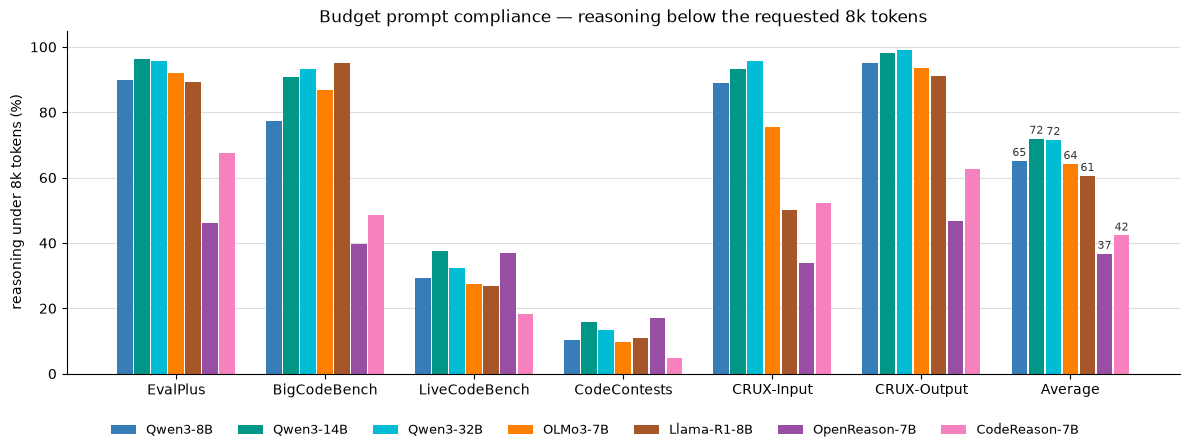

saved ../figures/07_budget_compliance.png


In [6]:
def compliance_rate(counts: dict[str, list], budget: int) -> float:
    """Fraction of samples whose reasoning stayed strictly below the budget.

    Returns the compliance rate as a float in [0, 1].
    """
    tokens = np.array(counts["tokens"])
    return float((tokens < budget).mean())


def plot_compliance_bars(save_path: Path) -> None:
    """Plot budget compliance per model for every benchmark plus the macro-average.

    One bar group per benchmark (and a final macro-average group), one coloured bar
    per model inside each group. The average group carries direct value labels; the
    printed summary table above doubles as the exact-value reference for the rest.
    Saves the figure as a PNG at save_path.
    """
    group_labels = list(DATASETS) + ["Average"]
    available = [k for k in SERIES if k in all_counts]
    n_bars = len(available)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    width = 0.8 / max(n_bars, 1)

    for bar_idx, series_key in enumerate(available):
        counts = all_counts[series_key]["budget"]

        # per-benchmark compliance; missing benchmarks are left out of the average
        per_benchmark = [
            compliance_rate(counts[stem], REQUESTED_BUDGET) if stem in counts else None
            for stem in DATASETS.values()
        ]
        present = [v for v in per_benchmark if v is not None]
        macro_avg = sum(present) / len(present) if present else None

        values = per_benchmark + [macro_avg]
        for group_idx, value in enumerate(values):
            if value is None:
                continue
            x = group_idx + (bar_idx - (n_bars - 1) / 2) * width
            ax.bar(
                x,
                value * 100,
                # small gap between neighbouring bars keeps same-family hues apart
                width=width * 0.92,
                color=SERIES[series_key]["colour"],
                label=SERIES[series_key]["label"] if group_idx == 0 else None,
            )
            # direct value labels on the macro-average group only
            if group_idx == len(values) - 1:
                ax.text(
                    x,
                    value * 100 + 1.5,
                    f"{value * 100:.0f}",
                    ha="center",
                    fontsize=8,
                    color="#333333",
                )

    ax.set_xticks(range(len(group_labels)))
    ax.set_xticklabels(group_labels)
    ax.set_ylim(0, 105)
    ax.set_ylabel(f"reasoning under {REQUESTED_BUDGET // 1000}k tokens (%)")
    ax.set_title(
        f"Budget prompt compliance — reasoning below the requested "
        f"{REQUESTED_BUDGET // 1000}k tokens",
    )
    # recessive horizontal grid behind the bars
    ax.grid(axis="y", color="#DDDDDD", linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    # single-row legend below the axis keeps all model chips clear of tall bars
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=n_bars,
        frameon=False,
        fontsize=9,
    )

    fig.tight_layout(rect=(0, 0.07, 1, 1))
    fig.savefig(save_path, dpi=200)
    plt.show()
    print(f"saved {save_path}")


plot_compliance_bars(save_path=FIGURES_DIR / "07_budget_compliance.png")

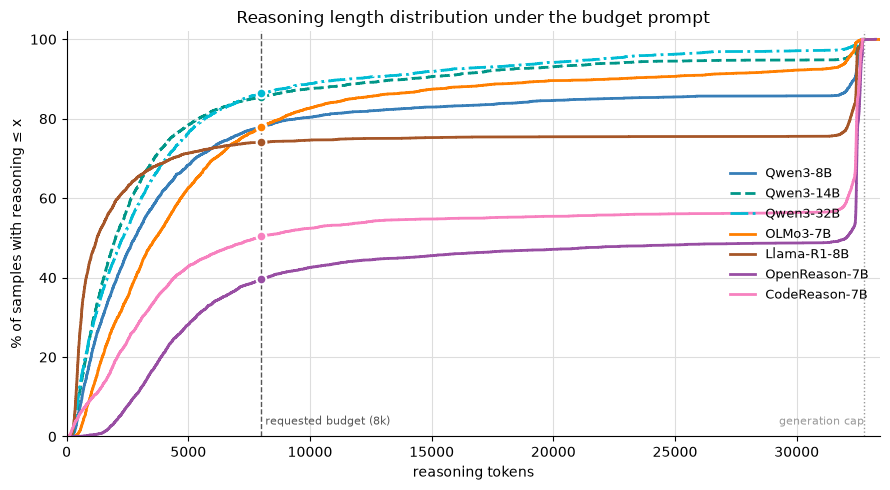

saved ../figures/07_budget_ecdf.png


In [7]:
def plot_reasoning_ecdf(save_path: Path) -> None:
    """Plot the cumulative distribution of reasoning length per model (budget run).

    Samples are pooled over all downloaded benchmarks (every sample counts equally).
    The curve height where it crosses the dashed budget line is exactly the model's
    compliance rate, marked with a dot per model.
    Saves the figure as a PNG at save_path.
    """
    fig, ax = plt.subplots(figsize=(9, 5))

    for series_key, runs in all_counts.items():
        counts = runs["budget"]
        tokens = np.sort([t for stem in counts for t in counts[stem]["tokens"]])
        if len(tokens) == 0:
            continue
        cumulative = np.arange(1, len(tokens) + 1) / len(tokens) * 100

        ax.plot(
            tokens,
            cumulative,
            drawstyle="steps-post",
            color=SERIES[series_key]["colour"],
            linestyle=SERIES[series_key]["linestyle"],
            linewidth=2,
            label=SERIES[series_key]["label"],
        )
        # dot where the curve crosses the budget line = the compliance rate
        compliance = (tokens < REQUESTED_BUDGET).mean() * 100
        ax.plot(
            REQUESTED_BUDGET,
            compliance,
            marker="o",
            markersize=7,
            color=SERIES[series_key]["colour"],
            # white ring keeps overlapping dots separable
            markeredgecolor="white",
            markeredgewidth=1.5,
            zorder=5,
        )

    # reference lines: the requested budget and the hard generation cap
    ax.axvline(REQUESTED_BUDGET, color="#555555", linestyle="--", linewidth=1)
    ax.text(
        REQUESTED_BUDGET,
        3,
        f" requested budget ({REQUESTED_BUDGET // 1000}k)",
        fontsize=8,
        color="#555555",
    )
    ax.axvline(MAX_TOKENS, color="#999999", linestyle=":", linewidth=1)
    ax.text(MAX_TOKENS, 3, " generation cap", fontsize=8, color="#999999", ha="right")

    ax.set_xlim(0, MAX_TOKENS * 1.02)
    ax.set_ylim(0, 102)
    ax.set_xlabel("reasoning tokens")
    ax.set_ylabel("% of samples with reasoning ≤ x")
    ax.set_title("Reasoning length distribution under the budget prompt")
    ax.grid(color="#DDDDDD", linewidth=0.8)
    ax.set_axisbelow(True)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    # centre-right keeps the legend clear of the cap label (bottom) and curves (top)
    ax.legend(frameon=False, fontsize=9, loc="center right")

    fig.tight_layout()
    fig.savefig(save_path, dpi=200)
    plt.show()
    print(f"saved {save_path}")


plot_reasoning_ecdf(save_path=FIGURES_DIR / "07_budget_ecdf.png")

In [8]:
def paired_over_budget(
    runs: dict[str, dict[str, dict[str, list]]],
) -> dict[str, np.ndarray]:
    """Pair baseline and budget samples task-by-task and flag over-budget reasoning.

    Greedy decoding gives one sample per task, so position i of a benchmark's details
    is the same task in both runs. Only benchmarks present in both runs (with matching
    sample counts) are paired.

    Returns {"baseline": bool array, "budget": bool array} of over-budget flags.
    """
    base_over: list[bool] = []
    bud_over: list[bool] = []

    for stem in DATASETS.values():
        if stem not in runs["baseline"] or stem not in runs["budget"]:
            continue
        base_tokens = runs["baseline"][stem]["tokens"]
        bud_tokens = runs["budget"][stem]["tokens"]
        if len(base_tokens) != len(bud_tokens):
            print(f"  [warn] {stem}: sample counts differ, skipped from pairing")
            continue
        base_over.extend(t >= REQUESTED_BUDGET for t in base_tokens)
        bud_over.extend(t >= REQUESTED_BUDGET for t in bud_tokens)

    return {"baseline": np.array(base_over), "budget": np.array(bud_over)}


# --- paired table: what did the budget instruction change vs. the baseline run? ---
# rescued = over 8k at baseline, under 8k with the budget prompt
# pushed over = under 8k at baseline, over 8k with the budget prompt

paired: dict[str, dict[str, np.ndarray]] = {}

print(
    f"{'model':<15} {'n':>6} {'base >8k':>9} {'budget >8k':>11} "
    f"{'rescued':>15} {'pushed over':>15}"
)
print("-" * 78)

for series_key, runs in all_counts.items():
    flags = paired_over_budget(runs)
    paired[series_key] = flags
    base, bud = flags["baseline"], flags["budget"]

    n = len(base)
    n_base_over = int(base.sum())
    n_under = n - n_base_over
    rescued = int((base & ~bud).sum())
    pushed = int((~base & bud).sum())

    # rates are relative to the group they act on: rescued out of baseline-over
    # tasks, pushed-over out of baseline-under tasks
    rescued_str = (
        f"{rescued:>5} ({rescued / n_base_over:>6.1%})" if n_base_over else "     —"
    )
    pushed_str = f"{pushed:>5} ({pushed / n_under:>6.1%})" if n_under else "     —"

    print(
        f"{SERIES[series_key]['label']:<15} {n:>6} {base.mean():>8.1%} "
        f"{bud.mean():>10.1%} {rescued_str:>15} {pushed_str:>15}"
    )

model                n  base >8k  budget >8k         rescued     pushed over
------------------------------------------------------------------------------
Qwen3-8B          3789    24.7%      21.9%    318 ( 34.0%)    215 (  7.5%)
Qwen3-14B         3789    14.6%      14.5%    139 ( 25.1%)    133 (  4.1%)
Qwen3-32B         3789    13.6%      13.6%     99 ( 19.2%)    100 (  3.1%)
OLMo3-7B          3789    36.4%      22.1%    681 ( 49.3%)    139 (  5.8%)
Llama-R1-8B       3789    30.6%      25.9%    402 ( 34.7%)    226 (  8.6%)
OpenReason-7B     3789    45.1%      60.4%    457 ( 26.8%)   1038 ( 49.9%)
CodeReason-7B     3789    54.7%      49.6%    733 ( 35.3%)    540 ( 31.5%)


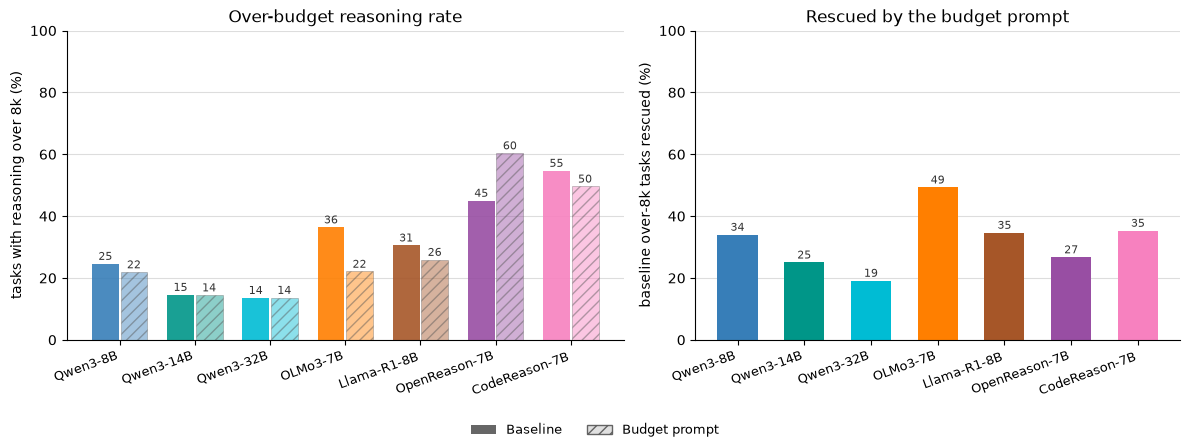

saved ../figures/07_budget_rescue.png


In [9]:
def plot_budget_rescue(save_path: Path) -> None:
    """Plot the budget prompt's effect on over-budget reasoning vs. the baseline.

    Left panel: % of tasks with reasoning over 8k, baseline (solid) vs. budget prompt
    (hatched), one bar pair per model. Right panel: of the tasks over 8k at baseline,
    the % the budget prompt brought under 8k (rescued). Both panels pool tasks over
    all benchmarks and carry direct value labels.
    Saves the figure as a PNG at save_path.
    """
    available = [k for k in SERIES if k in paired]
    positions = np.arange(len(available))

    fig, (ax_over, ax_rescue) = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(12, 4.5),
        width_ratios=[1.15, 1],
    )

    def _label(ax: plt.Axes, x: float, value: float) -> None:
        # direct value label just above a bar, in neutral ink
        ax.text(
            x, value + 1.2, f"{value:.0f}", ha="center", fontsize=8, color="#333333"
        )

    # --- left: over-8k rate, baseline vs budget prompt ---
    width = 0.38
    for idx, series_key in enumerate(available):
        colour = SERIES[series_key]["colour"]
        base = paired[series_key]["baseline"].mean() * 100
        bud = paired[series_key]["budget"].mean() * 100

        ax_over.bar(idx - width / 2, base, width=width * 0.94, color=colour, alpha=0.9)
        ax_over.bar(
            idx + width / 2,
            bud,
            width=width * 0.94,
            color=colour,
            alpha=0.45,
            hatch="///",
            edgecolor="#555555",
            linewidth=0.5,
        )
        _label(ax_over, idx - width / 2, base)
        _label(ax_over, idx + width / 2, bud)

    ax_over.set_ylabel("tasks with reasoning over 8k (%)")
    ax_over.set_title("Over-budget reasoning rate")

    # --- right: % of baseline-over tasks rescued by the budget prompt ---
    for idx, series_key in enumerate(available):
        base, bud = paired[series_key]["baseline"], paired[series_key]["budget"]
        n_over = base.sum()
        rescued = ((base & ~bud).sum() / n_over * 100) if n_over else 0.0

        ax_rescue.bar(idx, rescued, width=0.6, color=SERIES[series_key]["colour"])
        _label(ax_rescue, idx, rescued)

    ax_rescue.set_ylabel("baseline over-8k tasks rescued (%)")
    ax_rescue.set_title("Rescued by the budget prompt")

    for ax in (ax_over, ax_rescue):
        ax.set_xticks(positions)
        ax.set_xticklabels(
            [SERIES[k]["label"] for k in available],
            rotation=20,
            ha="right",
            fontsize=9,
        )
        ax.set_ylim(0, 100)
        ax.grid(axis="y", color="#DDDDDD", linewidth=0.8)
        ax.set_axisbelow(True)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)

    # shared legend for the left panel's solid/hatched pairing, in neutral grey
    legend_handles = [
        mpatches.Patch(facecolor="#555555", alpha=0.9, label="Baseline"),
        mpatches.Patch(
            facecolor="#DDDDDD",
            alpha=0.9,
            hatch="///",
            edgecolor="#555555",
            label="Budget prompt",
        ),
    ]
    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=2,
        frameon=False,
        fontsize=9,
    )

    fig.tight_layout(rect=(0, 0.07, 1, 1))
    fig.savefig(save_path, dpi=200)
    plt.show()
    print(f"saved {save_path}")


plot_budget_rescue(save_path=FIGURES_DIR / "07_budget_rescue.png")